In [1]:
import pandas as pd

In [2]:
!pip install pandas-datareader

In [3]:
import yfinance as yf
from datetime import datetime

df = yf.download('TSLA', start='2017-02-27', end='2022-02-24')

[*********************100%***********************]  1 of 1 completed


In [4]:
print(df.shape)
df.head()

(1258, 5)


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000


# **Visualizing Time-Series Data**

<Axes: xlabel='Date'>

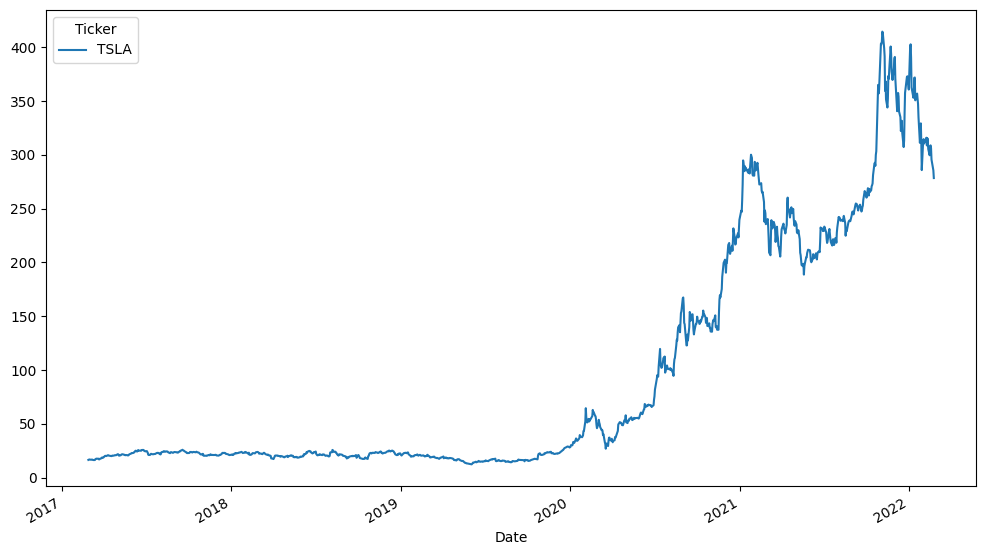

In [5]:
df['High'].plot(figsize=(12,7))

### Limiting graph by using `xlim` & `ylim`

<Axes: xlabel='Date'>

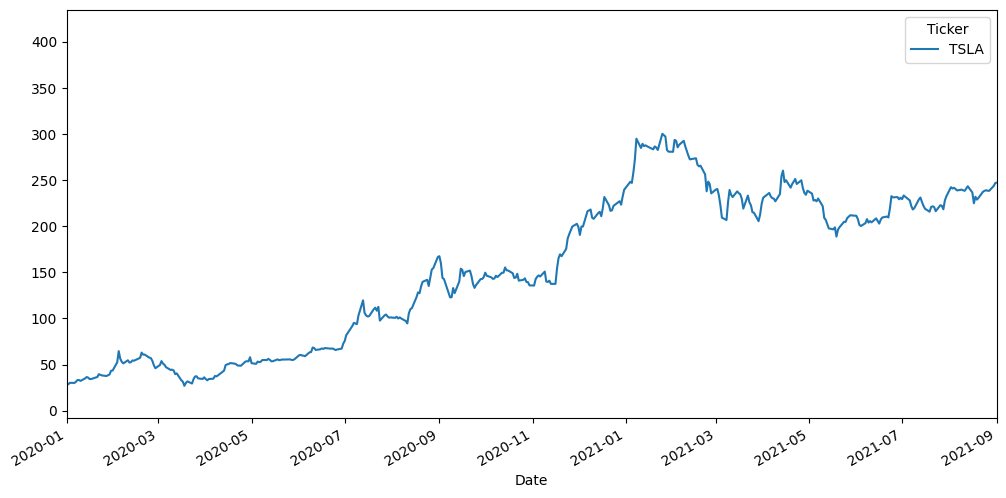

In [6]:
# Seeing/Zooming Graph by limiting x and y label
df['High'].plot(xlim=['2020-01-01','2021-09-01'], figsize=(12,6))

### Coloring & linestyle by using `c` & `ls` parameter

<Axes: xlabel='Date'>

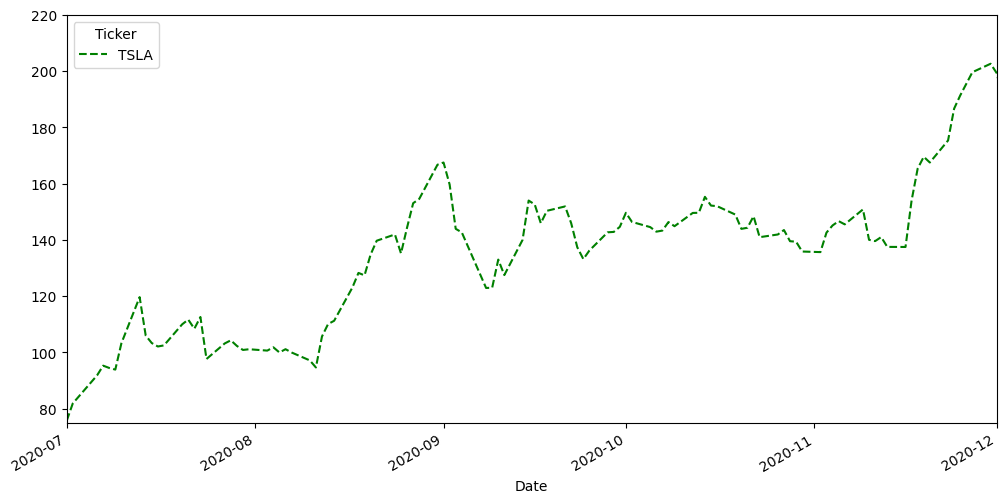

In [7]:
# Zooming deeper
df['High'].plot(xlim=['2020-07-01','2020-12-01'],ylim=[75,220], figsize=(12,6), c='green', ls='--')

### Index discussion

In [8]:
df.loc['2017-02-27':'2021-03-23']

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000
...,...,...,...,...,...
2021-03-17,233.936661,234.576660,217.003326,218.956665,121117500
2021-03-18,217.720001,229.743332,217.333328,228.096664,99674400


In [9]:
df.iloc[1:100]

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000
2017-03-06,16.747334,16.780001,16.500668,16.527332,50332500
...,...,...,...,...,...
2017-07-13,21.560667,22.106667,21.331333,22.007334,128917500
2017-07-14,21.851999,21.894667,21.414667,21.546000,84378000


In [10]:
index = df.loc['2020-01-01':'2021-09-01'].index
share_open = df.loc['2020-01-01':'2021-09-01']['Open']

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

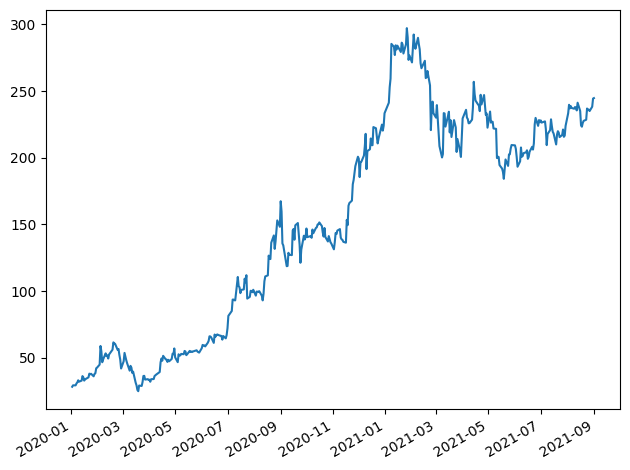

In [ ]:
figure,axis = plt.subplots()

axis.plot(index,share_open)

# Preventing overlapping of xlabels
figure.autofmt_xdate()
plt.tight_layout()

## Datetime Index

In [13]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000


In [14]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
1,2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2,2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
3,2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
4,2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000


If you want to revert this Date feature back to Index, you may use `set_index(df['Date'])` 
that is given below

In [15]:
df.set_index('Date')

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000
...,...,...,...,...,...
2022-02-16,307.796661,308.809998,300.403320,304.683319,51294300
2022-02-17,292.116669,306.166656,291.366669,304.420013,55178400


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   (Date, )        1258 non-null   datetime64[s]
 1   (Close, TSLA)   1258 non-null   float64      
 2   (High, TSLA)    1258 non-null   float64      
 3   (Low, TSLA)     1258 non-null   float64      
 4   (Open, TSLA)    1258 non-null   float64      
 5   (Volume, TSLA)  1258 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 59.1 KB


In [17]:
pd.to_datetime(df['Date'])

0      2017-02-27
1      2017-02-28
2      2017-03-01
3      2017-03-02
4      2017-03-03
          ...    
1253   2022-02-16
1254   2022-02-17
1255   2022-02-18
1256   2022-02-22
1257   2022-02-23
Name: Date, Length: 1258, dtype: datetime64[s]

In [18]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
1,2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2,2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
3,2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
4,2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000


### `datetime` operations

In [19]:
datetime.now()

datetime.datetime(2026, 6, 22, 19, 10, 0, 786415)

In [20]:
def time_difference(a,b):
    return abs(a-b)

In [21]:
start_time = datetime(2007,1,21)
end_time = datetime.now()
time_difference(start_time, end_time)

datetime.timedelta(days=7092, seconds=69000, microseconds=806909)

## **Time Resampling**

In [22]:
df = df.set_index('Date')


In [23]:
# Year end frequency
df.resample(rule='YE').min()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-12-31,16.246000,16.433332,16.134001,16.279333,43791000
2018-12-31,16.704000,17.355333,16.306000,16.851999,46210500
2019-12-31,11.931333,12.445333,11.799333,12.073333,36984000
2020-12-31,24.081333,26.990667,23.367332,24.980000,52073100
2021-12-31,187.666672,188.736664,179.830002,184.183334,29401800
2022-12-31,254.679993,278.433319,253.520004,276.809998,50729100


This above given table shows minimum values at Dates in the interval of a year 

<Axes: xlabel='Date'>

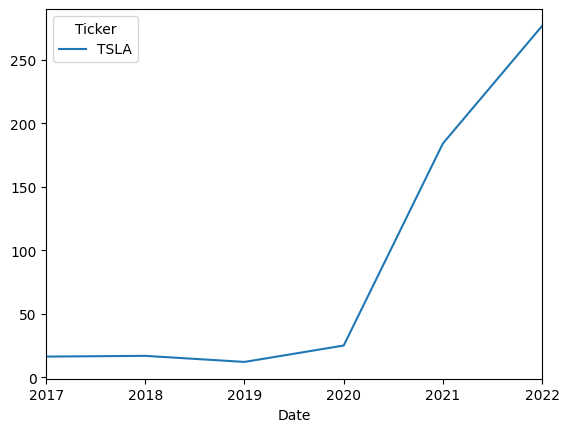

In [24]:
# May plot the above graph
df.resample('YE').min()['Open'].plot()

Types of rules in `resample` function

* 'YE'  =  Year end
* 'YS'  =  Year start
* 'ME'  =  Month end
* 'MS'  =  Month start
* 'QE'   = Quarterly end
* 'QS'   = Quarterly start
* 'W'   = Week

(These Business resamples consider Weekdays; Monday to Friday)

* 'BQE'   = Business Quarter End
* 'BME'   = Business Month End
* 'BA'    = Business year-end (Anual)



In [25]:
df.resample(rule='QS').min()['Open']

Ticker,TSLA
Date,
2017-01-01,16.279333
2017-04-01,19.126667
2017-07-01,20.860001
2017-10-01,19.966667
2018-01-01,17.099333
2018-04-01,16.851999
2018-07-01,17.340000
2018-10-01,17.016666
2019-01-01,17.313999


<Axes: xlabel='Date'>

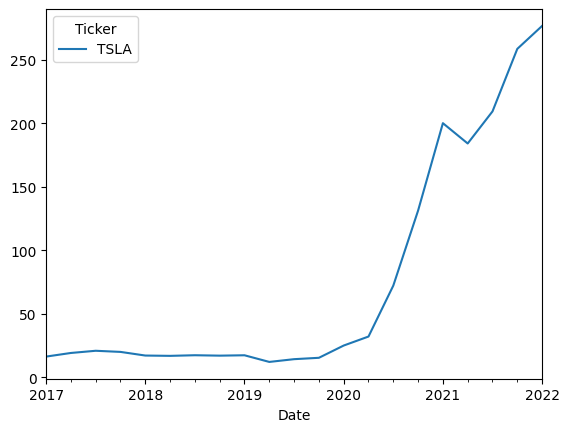

In [26]:
# Plotting
df.resample(rule='QS').min()['Open'].plot()

<Axes: xlabel='Date'>

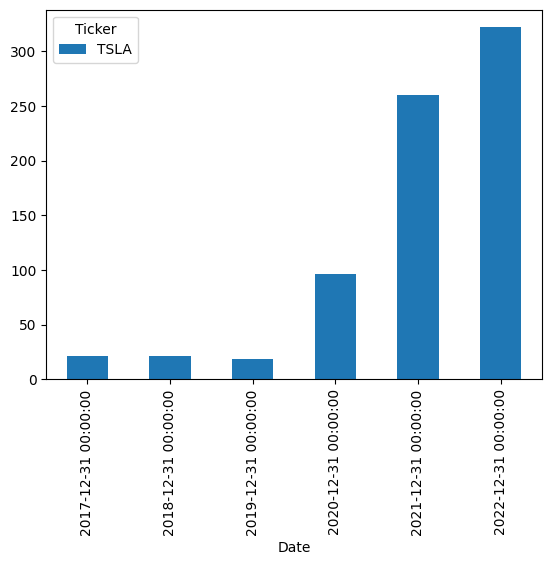

In [27]:
df['Open'].resample(rule='YE').mean().plot(kind='bar')

<Axes: xlabel='Date'>

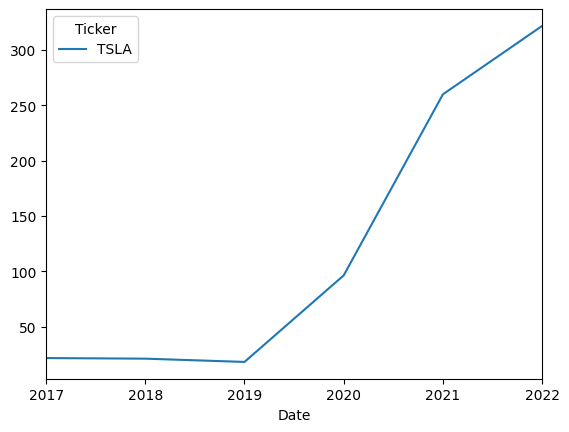

In [28]:
df['Open'].resample(rule='YE').mean().plot(kind='line')

# **Rolling and Expanding**
A `rolling window` means looking at a fixed number of previous observations and **calculating something** from them.

In [29]:
df.head(10)

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000
2017-03-06,16.747334,16.780001,16.500668,16.527332,50332500
2017-03-07,16.572666,16.926001,16.554667,16.794666,51892500
2017-03-08,16.458000,16.671333,16.354668,16.466667,55878000


Here we are calculating `mean` from window 

In [30]:
df['Close'].rolling(window=5).mean().head(10)

Ticker,TSLA
Date,
2017-02-27,NaN
2017-02-28,NaN
2017-03-01,NaN
2017-03-02,NaN
2017-03-03,16.643867
2017-03-06,16.710267
2017-03-07,16.691600
2017-03-08,16.649600
2017-03-09,16.575200


In [31]:
df['Open:30d_rolling'] = df['Open'].rolling(5).mean()

In [32]:
df.head(10)

Price,Close,High,Low,Open,Volume,Open:30d_rolling
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000,NaN
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500,NaN
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500,NaN
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000,NaN
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000,16.626533
2017-03-06,16.747334,16.780001,16.500668,16.527332,50332500,16.623066
2017-03-07,16.572666,16.926001,16.554667,16.794666,51892500,16.726133
2017-03-08,16.458000,16.671333,16.354668,16.466667,55878000,16.630400


<Axes: xlabel='Date'>

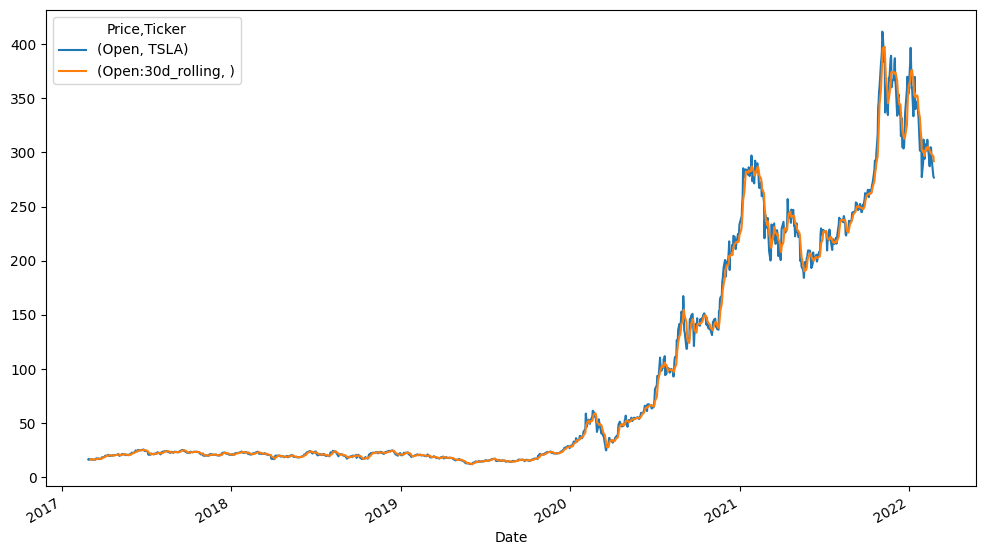

In [33]:
df[['Open','Open:30d_rolling']].plot(figsize=(12,7))